In [ ]:
import pandas as pd
import numpy as np

***Data Import***

In [ ]:
police_data = pd.read_csv('/content/PoliceIncidents_2026.csv')

***Data view and clean***

In [ ]:
police_data.head(10)

,Incident_Number,Date_Logged,Time_Logged,Department,Incident_Type,Location,ZipCode,Action_Taken,Officer,ObjectId
0,2026000045587,2026/05/01,23:59:00,Police,AMB - Ambulance Call,STAFFORD ST,01603,FD Call Only,NaN,1
1,2026000045542,2026/05/01,22:00:00,Police,DIP - Disorderly Person,DORCHESTER ST,,Resolved,Gary M Burnett,2
2,2026000045464,2026/05/01,19:17:00,Police,WAG - Transportation,QUEEN ST,01610,Arrest/PC,Neal R Sullivan,3
3,2026000045586,2026/05/01,23:59:00,Police,ANC - Animal Complaint,GREENWOOD ST,01607,Cancel,NaN,4
4,2026000045436,2026/05/01,18:31:00,Police,ASC - Assist Citizen,BAYBERRY RD,01606,Cancel,NaN,5
5,2026000045463,2026/05/01,19:17:00,Police,ACC - Accident Property Damage,PROVIDENCE ST,01604,Resolved,Gary M Burnett,6
6,2026000045542,2026/05/01,22:00:00,Police,DIP - Disorderly Person,DORCHESTER ST,,Resolved,Rachel E Frisch,7
7,2026000045586,2026/05/01,23:59:00,Police,CAN - Call Cancelled,GREENWOOD ST,01607,Cancel,NaN,8
8,2026000045435,2026/05/01,18:29:00,Police,ACH - Accident Hit and Run,LINCOLN ST,01605,Cancel,NaN,9
9,2026000045462,2026/05/01,19:14:00,Police,GNT - Grant,MILLBURY ST,01610,Resolved,Robert J Ouimet,10


In [ ]:
print(police_data.shape)

(82066, 10)


In [ ]:
print(police_data.columns)

Index(['Incident_Number', 'Date_Logged', 'Time_Logged', 'Department',
       'Incident_Type', 'Location', 'ZipCode', 'Action_Taken', 'Officer',
       'ObjectId'],
      dtype='object')


In [ ]:
print(police_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82066 entries, 0 to 82065
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   Incident_Number  82066 non-null  int64 
 1   Date_Logged      82066 non-null  object
 2   Time_Logged      82066 non-null  object
 3   Department       82066 non-null  object
 4   Incident_Type    82066 non-null  object
 5   Location         82066 non-null  object
 6   ZipCode          82066 non-null  object
 7   Action_Taken     81399 non-null  object
 8   Officer          69514 non-null  object
 9   ObjectId         82066 non-null  int64 
dtypes: int64(2), object(8)
memory usage: 6.3+ MB
None


In [ ]:
print(police_data.isnull().sum())

Incident_Number        0
Date_Logged            0
Time_Logged            0
Department             0
Incident_Type          0
Location               0
ZipCode                0
Action_Taken         667
Officer            12552
ObjectId               0
dtype: int64


In [ ]:
print(police_data['ZipCode'].unique()[:30])

['01603' '   ' '01610' '01607' '01606' '01604' '01605' '01608' '01609'
 '01602' '01655' '01653' '01613' '01614' '01612']


In [ ]:
print(police_data['ZipCode'].value_counts(dropna=False).head(20))

ZipCode
01604    16143
01610    13385
01605    13191
01609     8235
01608     8082
01603     7960
01606     4827
01602     4814
          2614
01607     2392
01655      297
01613       59
01653       37
01614       15
01612       15
Name: count, dtype: int64


In [ ]:
# we can see that the zip code column(string type) has missing values that were not caught by isnull()
# hence we repalce them by the nan

police_data['ZipCode'] = police_data['ZipCode'].replace(r'^\s*$', np.nan, regex=True)

In [ ]:
# now let us check agin for isnull()

print(police_data['ZipCode'].isnull().sum())

2614


In [ ]:
print(police_data.isnull().sum())

Incident_Number        0
Date_Logged            0
Time_Logged            0
Department             0
Incident_Type          0
Location               0
ZipCode             2614
Action_Taken         667
Officer            12552
ObjectId               0
dtype: int64


In [ ]:
# now we check how many types of deaprtments we have
print(police_data['Department'].unique())

['Police']


In [ ]:
print(police_data['Department'].value_counts(dropna=False))

Department
Police    82066
Name: count, dtype: int64


In [ ]:
# now we check top incident types by frequency
print(police_data['Incident_Type'].value_counts().head(20))

Incident_Type
AMB - Ambulance Call              13798
DIP - Disorderly Person            7196
CKW - Check on The Welfare         7175
MVC - MV Violations                5523
ASN - Assignment                   3648
ACC - Accident Property Damage     2787
ALC - Alarm Commercial             2776
WAG - Transportation               2333
ASC - Assist Citizen               2015
TOW - Tow Vehicle                  1706
ACI - Accident Personal Injury     1481
WAR - Warrant                      1343
DIS - Disturbance                  1317
ACH - Accident Hit and Run          935
ASD - Assist Other PD               887
TRC - Traffic Complaint             878
GPR - Guard Prisoner                841
HUP - 911 hang Up                   825
SHO - Shoplifting                   817
TRS - Trespass                      817
Name: count, dtype: int64


In [ ]:
# now we check the duplicate hypothesis that: multiple officeres are assigne dto some casese
duplicate_check = police_data.groupby([
    'Date_Logged',
    'Time_Logged',
    'Incident_Type',
    'Location',
    'ZipCode',
    'Action_Taken'
]).size().reset_index(name='count')

print(duplicate_check.sort_values('count', ascending=False).head(20))

      Date_Logged Time_Logged                        Incident_Type  \
32280  2026/03/31    16:46:00                    TOW - Tow Vehicle   
32279  2026/03/31    16:46:00                      GUN - Gun Shots   
14633  2026/02/12    01:10:00  ADW - Assault with Dangerous Weapon   
14635  2026/02/12    01:10:00              DIP - Disorderly Person   
14636  2026/02/12    01:10:00                      DOA - Dead Body   
21967  2026/03/04    19:41:00                UNK - Unknown Problem   
21966  2026/03/04    19:41:00                   GUP - Person w/Gun   
43371  2026/04/28    17:20:00                 WAG - Transportation   
43367  2026/04/28    17:20:00       FIW - Fight w/Dangerous Weapon   
43370  2026/04/28    17:20:00                UNK - Unknown Problem   
43369  2026/04/28    17:20:00                    TOW - Tow Vehicle   
3929   2026/01/12    16:21:00       FIW - Fight w/Dangerous Weapon   
29235  2026/03/23    13:44:00       ARC - Armed Robbery Commercial   
32790  2026/04/02   

In [ ]:
print(police_data['Officer'].value_counts(dropna=False).head(20))

Officer
NaN                      12552
Randy M Rodriguez          860
Trung Q Tran               818
Joseph L Tolson            782
Monicka Jean-Baptiste      694
Nikolas E Koulalis         690
Dante N Simone             676
Eusebio Bacova             665
Dimitrios Gaitanidis       664
Mousa Chamoun              653
Rachel E Frisch            653
Sandra J Carroll           647
Corey H Pham               643
Matthew J Lyons            627
Gary M Burnett             622
Dillon C George            618
Neyffi Sanchez             614
Domenic J Sacco            611
John Marcano Torres        608
Jafet L Ortiz              607
Name: count, dtype: int64


In [ ]:
police_data['Date_Logged'] = pd.to_datetime(police_data['Date_Logged'])

print(police_data['Date_Logged'].dtype)

datetime64[ns]


In [ ]:
print(police_data['Time_Logged'].head(10))

0    23:59:00
1    22:00:00
2    19:17:00
3    23:59:00
4    18:31:00
5    19:17:00
6    22:00:00
7    23:59:00
8    18:29:00
9    19:14:00
Name: Time_Logged, dtype: object


***Feature Engineering***

In [ ]:
police_data = police_data.drop(
    columns=['Department', 'ObjectId']
)

In [ ]:
incident_data = police_data.drop_duplicates(
    subset=[
        'Date_Logged',
        'Time_Logged',
        'Incident_Type',
        'Location',
        'ZipCode',
        'Action_Taken'
    ]
).copy()

In [ ]:
print("Operational Dataset Shape:", police_data.shape)
print("Incident Dataset Shape:", incident_data.shape)

Operational Dataset Shape: (82066, 8)
Incident Dataset Shape: (46654, 8)


In [ ]:
#convert the date column

incident_data['Date_Logged'] = pd.to_datetime(
    incident_data['Date_Logged']
)

In [ ]:
print(incident_data['Date_Logged'].dtype)

datetime64[ns]


In [ ]:
# convert time column

incident_data['Time_Logged'] = pd.to_datetime(
    incident_data['Time_Logged'],
    format='%H:%M:%S'
)

In [ ]:
print(incident_data['Time_Logged'].head())

0   1900-01-01 23:59:00
1   1900-01-01 22:00:00
2   1900-01-01 19:17:00
3   1900-01-01 23:59:00
4   1900-01-01 18:31:00
Name: Time_Logged, dtype: datetime64[ns]


In [ ]:
# now we create time features:

# time

incident_data['Hour'] = incident_data['Time_Logged'].dt.hour

In [ ]:
# daytime

incident_data['Day_Name'] = incident_data['Date_Logged'].dt.day_name()

In [ ]:
# month

incident_data['Month'] = incident_data['Date_Logged'].dt.month

In [ ]:
# year

incident_data['Year'] = incident_data['Date_Logged'].dt.year

In [ ]:
# weekedn flag

incident_data['Is_Weekend'] = incident_data['Day_Name'].isin([
    'Saturday',
    'Sunday'
])

In [ ]:
print(incident_data.head())

print(incident_data.info())

   Incident_Number Date_Logged         Time_Logged            Incident_Type  \
0    2026000045587  2026-05-01 1900-01-01 23:59:00     AMB - Ambulance Call   
1    2026000045542  2026-05-01 1900-01-01 22:00:00  DIP - Disorderly Person   
2    2026000045464  2026-05-01 1900-01-01 19:17:00     WAG - Transportation   
3    2026000045586  2026-05-01 1900-01-01 23:59:00   ANC - Animal Complaint   
4    2026000045436  2026-05-01 1900-01-01 18:31:00     ASC - Assist Citizen   

        Location ZipCode  Action_Taken          Officer  Hour Day_Name  Month  \
0    STAFFORD ST   01603  FD Call Only              NaN    23   Friday      5   
1  DORCHESTER ST     NaN      Resolved   Gary M Burnett    22   Friday      5   
2       QUEEN ST   01610     Arrest/PC  Neal R Sullivan    19   Friday      5   
3   GREENWOOD ST   01607        Cancel              NaN    23   Friday      5   
4    BAYBERRY RD   01606        Cancel              NaN    18   Friday      5   

   Year  Is_Weekend  
0  2026       Fa

***Incident Volume Analysis***

In [ ]:
# Which incident types are most common?
# Which hours are busiest?
# Which days are busiest?
# Which months are busiest?

In [ ]:
# incident by hour:

hourly_incidents = incident_data.groupby('Hour').size()

print(hourly_incidents)

Hour
0     1580
1     1385
2     1097
3      820
4      630
5      620
6      929
7     1579
8     2245
9     2586
10    2697
11    2718
12    2600
13    2667
14    2345
15    2426
16    3028
17    2975
18    2488
19    2450
20    2075
21    1791
22    1421
23    1502
dtype: int64


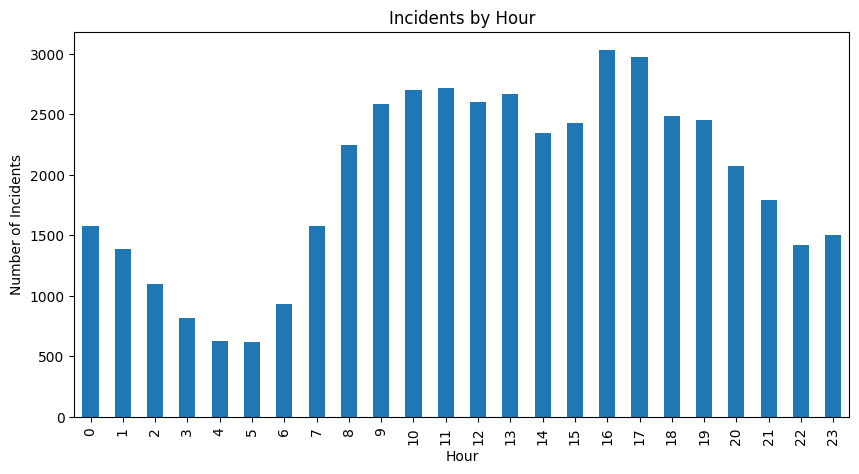

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

hourly_incidents.plot(kind='bar')

plt.xlabel('Hour')
plt.ylabel('Number of Incidents')
plt.title('Incidents by Hour')

plt.show()

In [ ]:
# incident by day

day_incidents = incident_data['Day_Name'].value_counts()

print(day_incidents)

Day_Name
Friday       7757
Thursday     7385
Tuesday      7046
Wednesday    6981
Monday       6312
Saturday     5909
Sunday       5264
Name: count, dtype: int64


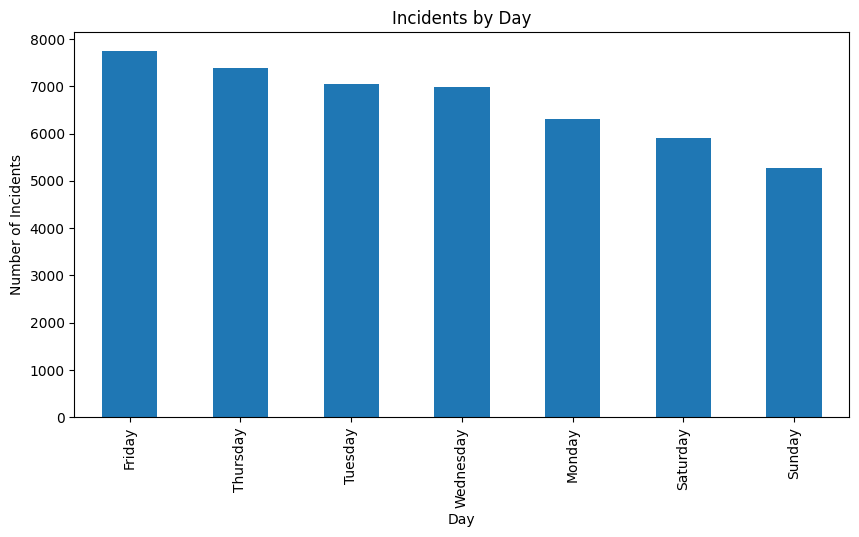

In [ ]:
plt.figure(figsize=(10,5))

day_incidents.plot(kind='bar')

plt.xlabel('Day')
plt.ylabel('Number of Incidents')
plt.title('Incidents by Day')

plt.show()

In [ ]:
# top inc. type

top_incidents = incident_data['Incident_Type'].value_counts().head(10)

print(top_incidents)

Incident_Type
AMB - Ambulance Call              11161
MVC - MV Violations                3576
DIP - Disorderly Person            3296
CKW - Check on The Welfare         3224
ASN - Assignment                   2421
ACC - Accident Property Damage     1797
ALC - Alarm Commercial             1413
ASC - Assist Citizen               1346
TRC - Traffic Complaint             775
ACH - Accident Hit and Run          772
Name: count, dtype: int64


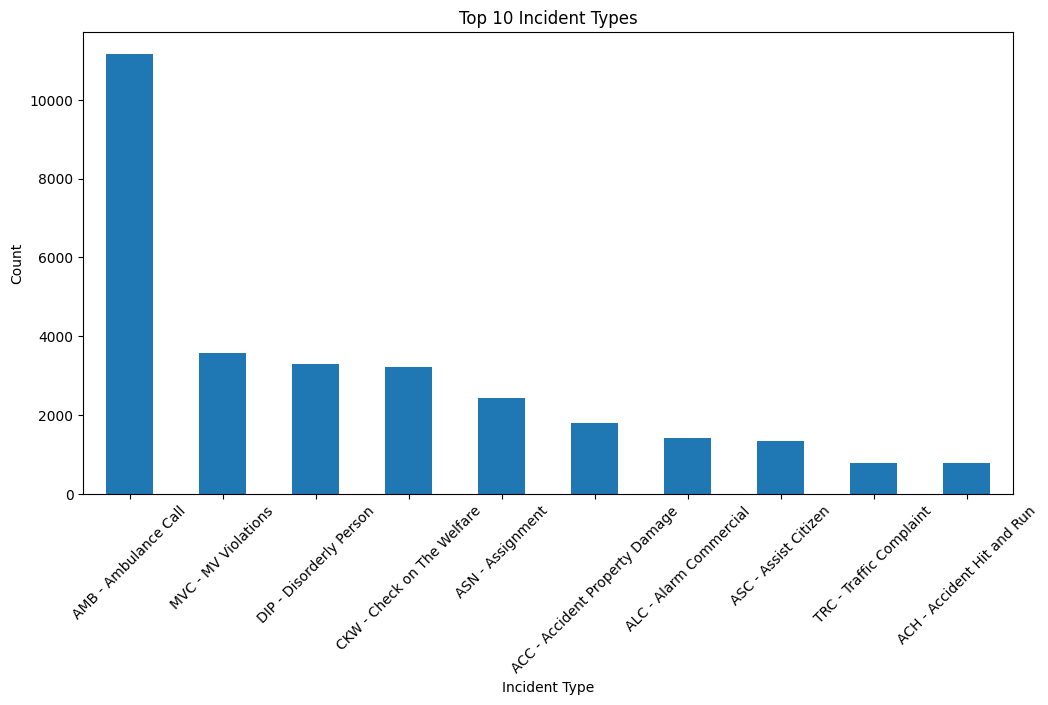

In [ ]:
plt.figure(figsize=(12,6))

top_incidents.plot(kind='bar')

plt.xlabel('Incident Type')
plt.ylabel('Count')
plt.title('Top 10 Incident Types')

plt.xticks(rotation=45)

plt.show()

In [ ]:
# zip code hotspots

zip_incidents = incident_data['ZipCode'].value_counts()

print(zip_incidents)

ZipCode
01604    9304
01605    7387
01610    7295
01609    4794
01603    4453
01608    4071
01606    3128
01602    3052
01607    1414
01655     171
01613      30
01653      25
01612      12
01614       7
Name: count, dtype: int64


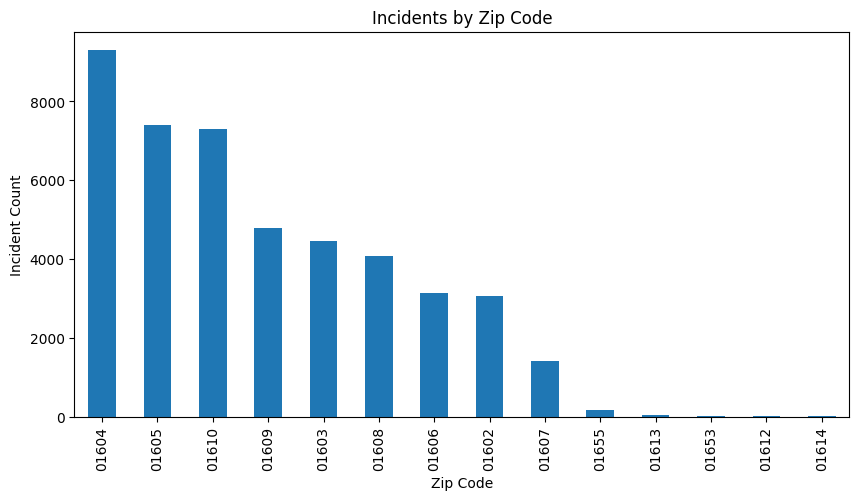

In [ ]:
plt.figure(figsize=(10,5))

zip_incidents.plot(kind='bar')

plt.xlabel('Zip Code')
plt.ylabel('Incident Count')
plt.title('Incidents by Zip Code')

plt.show()

In [ ]:
# heatmap:

pivot_table = incident_data.pivot_table(
    index='Day_Name',
    columns='Hour',
    values='Incident_Number',
    aggfunc='count'
)

print(pivot_table)

Hour        0    1    2    3    4    5    6    7    8    9   ...   14   15  \
Day_Name                                                     ...             
Friday     210  141  165  114   90   93  154  277  440  481  ...  405  430   
Monday     170  156  126  109   71   95  108  247  275  318  ...  327  320   
Saturday   297  281  215  143   86   81  117  195  248  261  ...  292  268   
Sunday     356  327  219  147  118   71  126  126  156  201  ...  263  258   
Thursday   168  165  148  120   94  102  156  266  409  480  ...  381  411   
Tuesday    188  165  120   93   85  100  122  239  308  396  ...  321  391   
Wednesday  191  150  104   94   86   78  146  229  409  449  ...  356  348   

Hour        16   17   18   19   20   21   22   23  
Day_Name                                           
Friday     435  446  388  361  324  315  273  315  
Monday     469  436  363  348  292  223  170  173  
Saturday   297  306  298  296  260  275  222  299  
Sunday     245  300  244  244  243  2

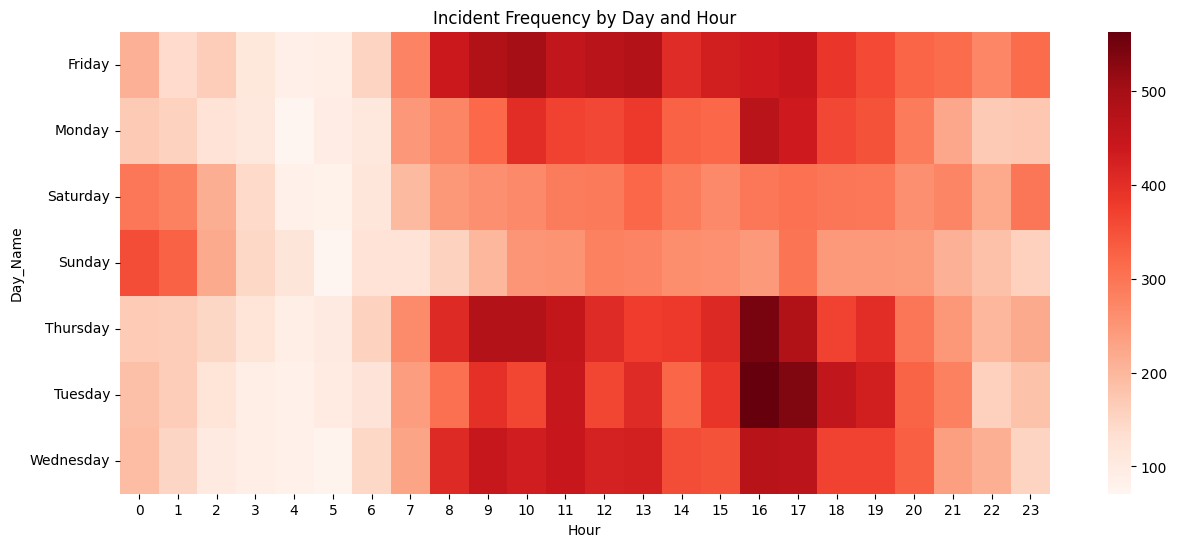

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(15,6))

sns.heatmap(
    pivot_table,
    cmap='Reds'
)

plt.title('Incident Frequency by Day and Hour')

plt.show()

In [ ]:
# geographic-temporal hotspot analysis

zip_hour = incident_data.pivot_table(
    index='ZipCode',
    columns='Hour',
    values='Incident_Number',
    aggfunc='count'
)

print(zip_hour)

Hour        0      1      2      3      4      5      6      7      8      9   \
ZipCode                                                                         
01602     73.0   51.0   74.0   34.0   39.0   49.0   57.0  150.0  182.0  168.0   
01603    152.0  171.0  123.0   70.0   52.0   67.0   99.0  144.0  198.0  269.0   
01604    326.0  284.0  208.0  180.0  123.0  127.0  202.0  318.0  518.0  485.0   
01605    250.0  194.0  140.0  141.0   96.0  107.0  160.0  254.0  329.0  373.0   
01606     62.0   47.0   36.0   42.0   37.0   45.0   72.0  113.0  192.0  253.0   
01607     42.0   29.0   20.0   20.0   17.0   16.0   43.0   52.0   58.0   78.0   
01608    150.0  151.0  132.0   77.0   71.0   51.0   62.0  134.0  171.0  232.0   
01609    163.0  122.0  120.0   75.0   63.0   46.0   74.0  170.0  223.0  235.0   
01610    288.0  287.0  206.0  157.0   98.0   87.0  137.0  185.0  260.0  402.0   
01612      1.0    NaN    NaN    NaN    1.0    NaN    NaN    NaN    NaN    1.0   
01613      1.0    NaN    NaN

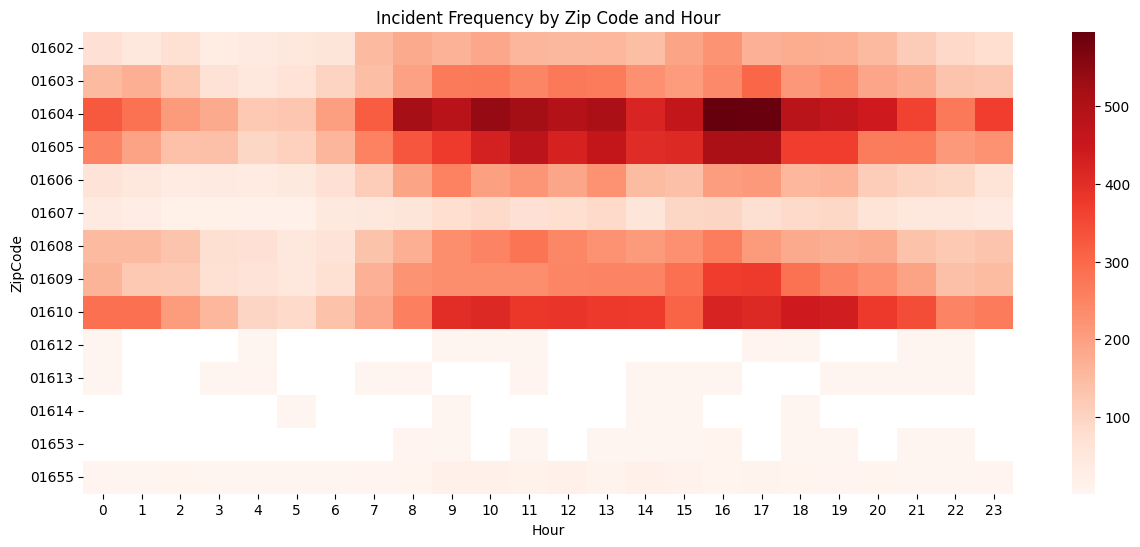

In [ ]:
plt.figure(figsize=(15,6))

sns.heatmap(
    zip_hour,
    cmap='Reds'
)

plt.title('Incident Frequency by Zip Code and Hour')

plt.show()

***Prediction part***

In [ ]:
# risk scoring:

risk_table = incident_data.groupby(
    ['ZipCode', 'Hour']
).size().reset_index(name='Incident_Count')

print(risk_table.head())

  ZipCode  Hour  Incident_Count
0   01602     0              73
1   01602     1              51
2   01602     2              74
3   01602     3              34
4   01602     4              39


In [ ]:
risk_table['Risk_Score'] = (
    risk_table['Incident_Count']
    / risk_table['Incident_Count'].max()
)

In [ ]:
risk_table['Risk_Level'] = pd.cut(
    risk_table['Risk_Score'],
    bins=[0, 0.33, 0.66, 1],
    labels=['Low', 'Medium', 'High']
)

In [ ]:
print(
    risk_table.sort_values(
        'Risk_Score',
        ascending=False
    ).head(20)
)

    ZipCode  Hour  Incident_Count  Risk_Score Risk_Level
64    01604    16             596    1.000000       High
65    01604    17             592    0.993289       High
58    01604    10             538    0.902685       High
59    01604    11             523    0.877517       High
56    01604     8             518    0.869128       High
89    01605    17             512    0.859060       High
61    01604    13             512    0.859060       High
88    01605    16             509    0.854027       High
60    01604    12             495    0.830537       High
57    01604     9             485    0.813758       High
66    01604    18             482    0.808725       High
83    01605    11             478    0.802013       High
67    01604    19             466    0.781879       High
85    01605    13             464    0.778523       High
63    01604    15             464    0.778523       High
210   01610    18             442    0.741611       High
68    01604    20             4

In [ ]:
# visual

top_risk = risk_table.sort_values(
    'Risk_Score',
    ascending=False
).head(15)

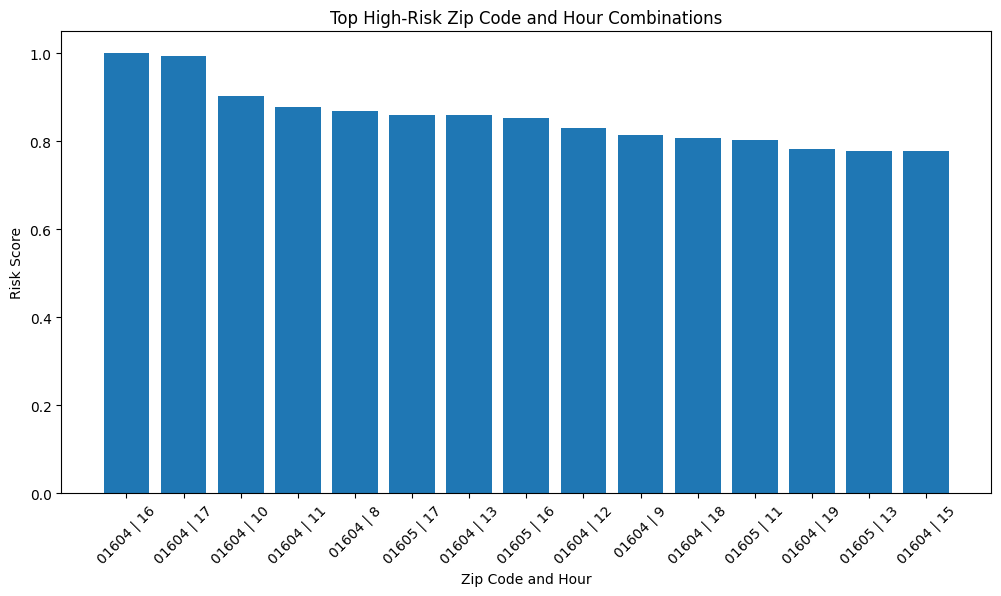

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.bar(
    top_risk['ZipCode'].astype(str) + " | " + top_risk['Hour'].astype(str),
    top_risk['Risk_Score']
)

plt.xticks(rotation=45)

plt.xlabel('Zip Code and Hour')
plt.ylabel('Risk Score')
plt.title('Top High-Risk Zip Code and Hour Combinations')

plt.show()



1.   Which ZIP codes need higher patrol attention?
2.   During which hours?
3.   Which time windows are highest priority?
4.   Where should limited patrol resources focus first?



In [ ]:
patrol_plan = risk_table.copy()

In [ ]:
# recom. rules

patrol_plan['Patrol_Recommendation'] = patrol_plan['Risk_Level'].map({
    'High': 'Increase Patrol Presence',
    'Medium': 'Moderate Patrol Coverage',
    'Low': 'Routine Monitoring'
})

In [ ]:
high_risk_patrols = patrol_plan[
    patrol_plan['Risk_Level'] == 'High'
]

print(
    high_risk_patrols.sort_values(
        'Risk_Score',
        ascending=False
    ).head(20)
)

    ZipCode  Hour  Incident_Count  Risk_Score Risk_Level  \
64    01604    16             596    1.000000       High   
65    01604    17             592    0.993289       High   
58    01604    10             538    0.902685       High   
59    01604    11             523    0.877517       High   
56    01604     8             518    0.869128       High   
61    01604    13             512    0.859060       High   
89    01605    17             512    0.859060       High   
88    01605    16             509    0.854027       High   
60    01604    12             495    0.830537       High   
57    01604     9             485    0.813758       High   
66    01604    18             482    0.808725       High   
83    01605    11             478    0.802013       High   
67    01604    19             466    0.781879       High   
85    01605    13             464    0.778523       High   
63    01604    15             464    0.778523       High   
210   01610    18             442    0.7

In [ ]:
top_patrols = high_risk_patrols.sort_values(
    'Risk_Score',
    ascending=False
).head(15)

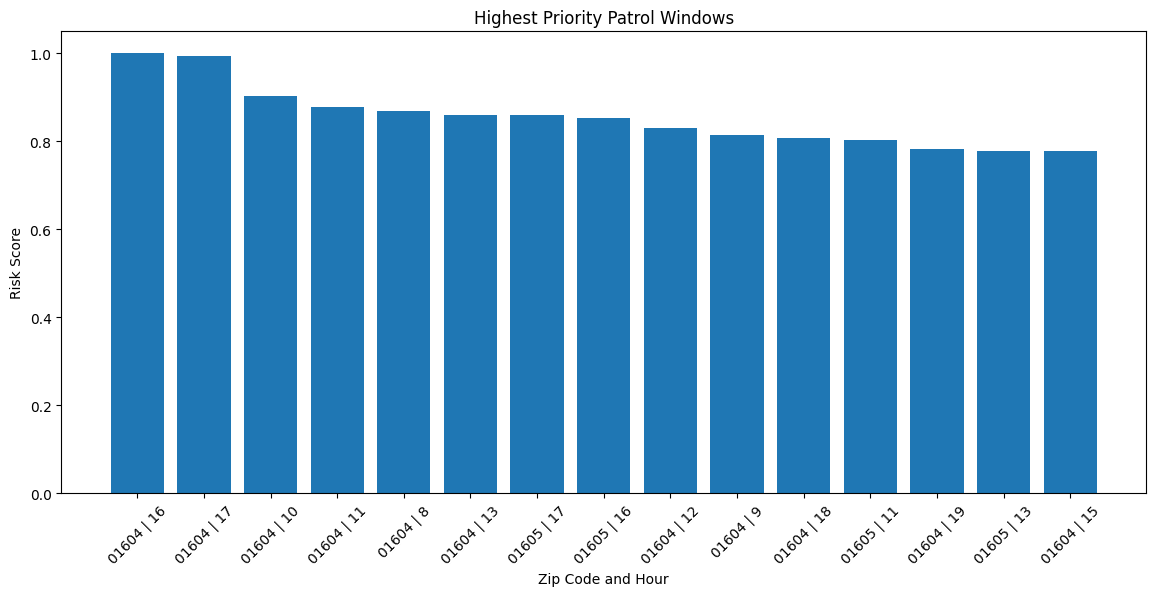

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14,6))

plt.bar(
    top_patrols['ZipCode'].astype(str) + " | " + top_patrols['Hour'].astype(str),
    top_patrols['Risk_Score']
)

plt.xticks(rotation=45)

plt.xlabel('Zip Code and Hour')
plt.ylabel('Risk Score')

plt.title('Highest Priority Patrol Windows')

plt.show()

***modelling***

In [ ]:
model_data = incident_data.groupby(
    ['ZipCode', 'Hour', 'Day_Name', 'Month', 'Is_Weekend']
).size().reset_index(name='Incident_Count')

In [ ]:
print(model_data.head())

print(model_data.shape)

  ZipCode  Hour Day_Name  Month  Is_Weekend  Incident_Count
0   01602     0   Friday      1       False               1
1   01602     0   Friday      2       False               5
2   01602     0   Friday      3       False               3
3   01602     0   Friday      4       False               4
4   01602     0   Friday      5       False               3
(6056, 6)


In [ ]:
model_encoded = pd.get_dummies(
    model_data,
    columns=['ZipCode', 'Day_Name'],
    drop_first=True
)

In [ ]:
X = model_encoded.drop(columns=['Incident_Count'])

y = model_encoded['Incident_Count']

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [ ]:
predictions = rf_model.predict(X_test)

In [ ]:
from sklearn.metrics import mean_absolute_error, r2_score

mae = mean_absolute_error(y_test, predictions)

r2 = r2_score(y_test, predictions)

print("MAE:", mae)
print("R2 Score:", r2)

MAE: 2.771732673267327
R2 Score: 0.6151047534975524


In [ ]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': predictions
})

print(comparison.head(20))

    Actual  Predicted
0        7       8.99
1        1       2.39
2        6      10.33
3       12      14.43
4        1       4.07
5        5       8.09
6        5       5.16
7        2       3.60
8        2       2.07
9        4       3.50
10      10       4.65
11       5       3.03
12      25      22.44
13      21      25.72
14       2       1.14
15       8       9.51
16       3       5.60
17      14      15.84
18       8      10.86
19      11      14.06


In [ ]:
# feature imp

feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [ ]:
feature_importance = feature_importance.sort_values(
    'Importance',
    ascending=False
)

print(feature_importance.head(15))

               Feature  Importance
0                 Hour    0.345351
4        ZipCode_01604    0.134802
1                Month    0.125532
10       ZipCode_01610    0.074411
5        ZipCode_01605    0.071641
2           Is_Weekend    0.048868
20    Day_Name_Tuesday    0.027096
16     Day_Name_Monday    0.023421
7        ZipCode_01607    0.022755
19   Day_Name_Thursday    0.022632
21  Day_Name_Wednesday    0.021594
15       ZipCode_01655    0.015653
18     Day_Name_Sunday    0.013921
9        ZipCode_01609    0.010682
3        ZipCode_01603    0.009875


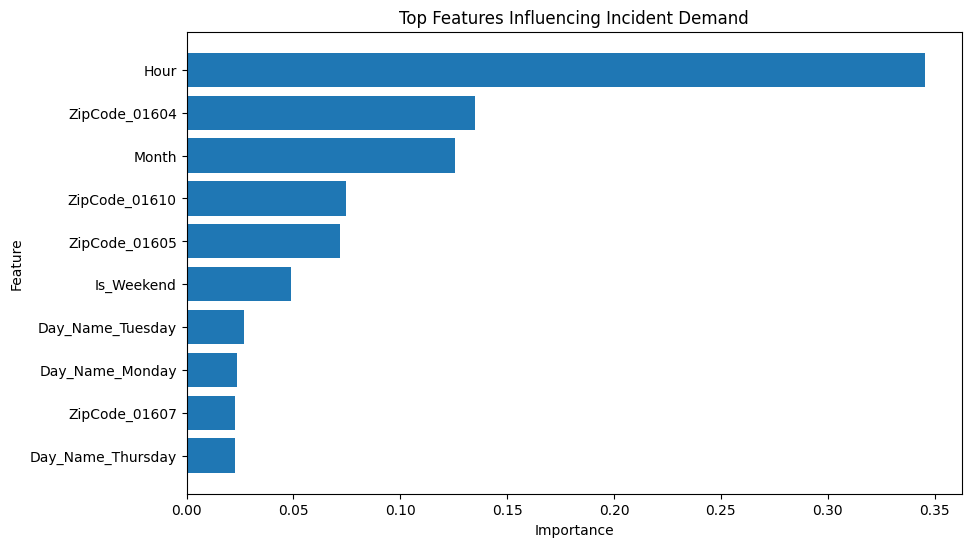

In [ ]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(10)

plt.figure(figsize=(10,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance')
plt.ylabel('Feature')

plt.title('Top Features Influencing Incident Demand')

plt.gca().invert_yaxis()

plt.show()

Time of day

Geographic area

Seasonal timing

In [ ]:
comparison['Predicted'] = comparison['Predicted'].round(2)

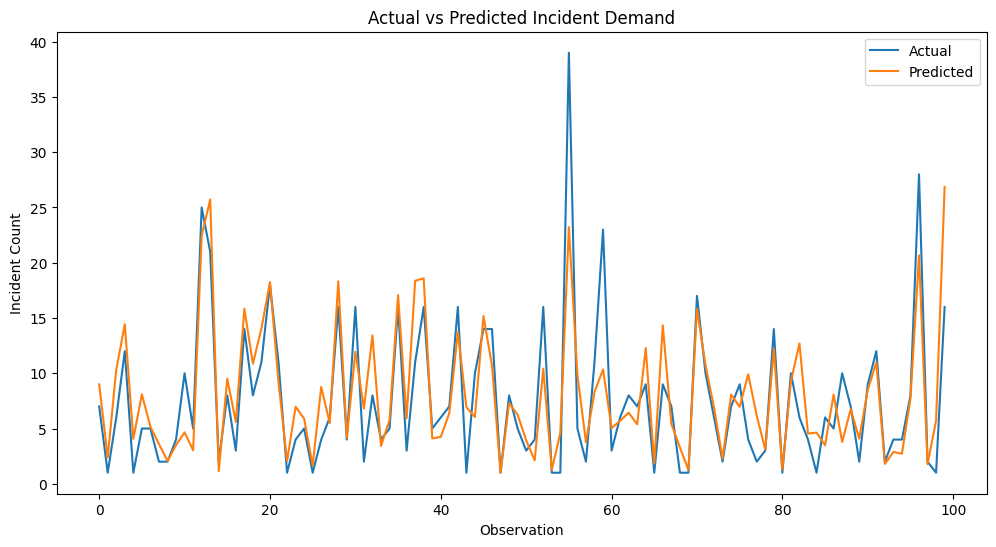

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    comparison['Actual'].values[:100],
    label='Actual'
)

plt.plot(
    comparison['Predicted'].values[:100],
    label='Predicted'
)

plt.xlabel('Observation')

plt.ylabel('Incident Count')

plt.title('Actual vs Predicted Incident Demand')

plt.legend()

plt.show()

In [ ]:
risk_table['Demand_Tier'] = pd.qcut(
    risk_table['Incident_Count'],
    q=4,
    labels=[
        'Minimal Demand',
        'Normal Demand',
        'Elevated Demand',
        'Critical Demand'
    ]
)

In [ ]:
print(
    risk_table['Demand_Tier'].value_counts()
)

Demand_Tier
Minimal Demand     70
Normal Demand      70
Elevated Demand    69
Critical Demand    69
Name: count, dtype: int64


In [ ]:
critical_windows = risk_table[
    risk_table['Demand_Tier'] == 'Critical Demand'
]

print(
    critical_windows.sort_values(
        'Incident_Count',
        ascending=False
    ).head(20)
)

    ZipCode  Hour  Incident_Count  Risk_Score Risk_Level      Demand_Tier
64    01604    16             596    1.000000       High  Critical Demand
65    01604    17             592    0.993289       High  Critical Demand
58    01604    10             538    0.902685       High  Critical Demand
59    01604    11             523    0.877517       High  Critical Demand
56    01604     8             518    0.869128       High  Critical Demand
89    01605    17             512    0.859060       High  Critical Demand
61    01604    13             512    0.859060       High  Critical Demand
88    01605    16             509    0.854027       High  Critical Demand
60    01604    12             495    0.830537       High  Critical Demand
57    01604     9             485    0.813758       High  Critical Demand
66    01604    18             482    0.808725       High  Critical Demand
83    01605    11             478    0.802013       High  Critical Demand
67    01604    19             466    0

In [ ]:
incident_data.to_csv(
    'incident_data.csv',
    index=False
)

In [ ]:
risk_table.to_csv(
    'risk_table.csv',
    index=False
)

In [ ]:
patrol_plan.to_csv(
    'patrol_plan.csv',
    index=False
)

In [ ]:
comparison.to_csv(
    'prediction_comparison.csv',
    index=False
)

In [ ]:
incident_data.to_csv('incident_data.csv', index=False)

risk_table.to_csv('risk_table.csv', index=False)

patrol_plan.to_csv('patrol_plan.csv', index=False)

comparison.to_csv('prediction_comparison.csv', index=False)